# 2 Statistical Learning

In [2]:
import pandas as pd

## 2.1 What is Statistical Learning?

Suppose we observe $p$ different predictors $X = (X_1, X_2, \ldots, X_p)\in\mathbb{R}^p$ and a quantitative response $Y\in\mathbb{R}$. We assume that there exists a relationship $f$ between $Y$ and $X$ that can be written as $$Y=f(X)+\varepsilon,$$ where $f:\mathbb{R}^p\to\mathbb{R}$ is a fixed but unknown function  $\varepsilon$ is a random *error* term, which is independent of $X$ and has mean zero. 

In essence, statistical learning refers to a set of approaches for estimating $f$.

### 2.1.1 Why Estimate $f$?

1. Prediction
2. Inference

#### Prediction

In some situations, a set of inputs $X$ are available but the output $Y$ is not. Since the error term averages out to zero, we can predict $Y$ using $$\hat{Y} = \hat{f}(X),$$ where $\hat{f}$ is our estimate for $f$ and $\hat{Y}$ is the resulting prediction for $Y$. 

The accuracy of $\hat{Y}$ as a prediction for $Y$ depends on the reducible error and the irreducible error.
- **reducible error**: In general, $\hat{f}$ will not be a perfect estimate for $f$, and this inaccuracy introduces some error. However, we can *reduce* this error by using the most appropriate/powerful learning technique to estimate a better approximation $\hat{f}$ to $f$.
- **irreducible error**: Even if we found the exact value of $f$ so that $\hat{Y} = \hat{f}(X) = f(X)$ (i.e. $\hat{f}=f$), we'd still have variability associated with $\varepsilon$ affecting our accuracy. Since this error is independent of $X$, it cannot be predicted using $X$, thus it's *irreducible*. 

Assume that $\hat{f}$ and $X$ are fixed. If we let $Y=f(X) + \varepsilon$ and $\hat{Y} = \hat{f}(X)$, then the only variability comes from $\varepsilon$ and we have 
$$
\begin{aligned}
    E(Y-\hat{Y})^2 &= E\left[f(X) + \varepsilon - \hat{f}(X)\right]^2\\
    &= \left(f(X)-\hat{f}(X)\right)^2 + \operatorname{Var}(\varepsilon). 
\end{aligned}
$$

Here, $\left(f(X)-\hat{f}(X)\right)^2$ is the **reducible error** and $\operatorname{Var}(\varepsilon)$ is the **irreducible error**. 

#### Inference
We might be interested in understanding the association between $X$ and $Y$, but not necessarily make predictions for $Y$. Therefore we can't treat $\hat{f}$ as a black box as above.
- *Which predictors are associated with the response?*
- *What is the relationship between the response and each predictor?*
- *Can the relationship between $Y$ and each predictor $X_j$ be summarized adequately using a linear equation, or is the relationship more complicated?*

Linear models allow for simpler and more interpretable inference, but may not be as accurate. Contrastingly, nonlinear models may provide more accurate predictions but will not be as easily interpretable. 

### 2.1.2 How Do We Estimate $f$?

Assume that we've observed a set of $n$ different data points (training data) consisting of $p$ different predictors (features) each. Let $y_i$ represent the response variable for the $i$th data point. Our training data thus consists of pairs $\{(x_1, y_1),\ldots,(x_n,y_n)\}$ where $x_i = (x_{i,1},\ldots,x_{i,p})^T$. 

Our goal is to find an $\hat{f}$ such that $Y \approx \hat{f}(X)$ using the training data. There are two types of approaches, parametric and nonparametric.

#### Parametric Methods 
Two-step model-based approach.

1. Select a model by assuming the functional form of $f$ (e.g. that $f$ is linear in $X$) involving some parameters. Thus, instead of estimating an arbitrary function, we only have to estimate the *parameters*.
2. Fit or train the model. For example, fit a linear model using ordinary least squares. 

#### Non-Parametric Methods
These methods don't make explicit assumptions about the functional form of $f$, but rather seek an estimate of $f$ that gets as close as possible to the data points without being too rough or wiggly. However, since they don't reduce the problem of $f$ to estimating a small number of parameters, they require a lot of data in order to be accurate. They also might be more inclined to overfit the data. 

### 2.1.3 The Trade-Off Between Prediction Accuracy and Model Interpretability
Why choose a more restrictive method instead of a very flexible one?

If we're interested in inference, then restrictive models are more interpretable. They may also be easier to train. Additionally, they may predict the data relatively well while being less prone to overfitting. 

### 2.1.4 Supervised Versus Unsupervised Learning

### 2.1.5 Regression Versus Classification Problems

## 2.2 Assessing model accuracy

### 2.2.1 Measuring the Quality of Fit
In the regression setting, we commonly use the *mean squared error* (MSE), given by $$MSE = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{f}(x_i))^2.$$ Note that this is really the *training MSE* since we compute it using the training data. What we really care about is *test MSE*. 

In practice, computing training MSE is relatively easy but estimating test MSE might be considerably more difficult. One method for doing so is *cross-validation*, see Ch. 5. 

### 2.2.2 The Bias-Variance Trade-Off
The expected test MSE for a given test sample $x_0$ can always be decomposed as the sum of three fundamental quantities:
1. The *variance* of $\hat{f}(x_0)$,
2. The squared *bias* of $\hat{f}(x_0)$, and
3. The variance $\operatorname{Var}\varepsilon$ of the error terms $\varepsilon$. 
That is, 
$$
E\left(y_0 - \hat{f}(x_0)\right)^2 = \operatorname{Var}(\hat{f}(x_0)) + [\operatorname{Bias}(\hat{f}(x_0))]^2 + \operatorname{Var}(\varepsilon). 
$$

The expression on the lefthand side of the equation is the expected test MSE at $x_0$. We can compute the *overall* expected test MSE can be computed by averaging this quantity over all possible values $x_0$ in the test set. 

The above equation tells us that to minimize expected test MSE, we need to simultaneously achieve low variance and low bias. Note all quantities on the RHS are non-negative, so the expected test MSE is bounded below by the variance of the error terms. 

- **variance*** refers to the amount by which $\hat{f}$ would change if we estimated it using a different training set. Ideally the estimate for $f$ should not change too much between training sets, but if small changes in training data result in large changes in $\hat{f}$ then the method is said to have high variance. 
- **bias** refers to the error that's introduced by approximating a real-life problem which may be extremely complex using a relatively simpler model. 

As we use more flexible methods, the variance will increase and the bias will decrease (usually). The relative rate of change of these quantities determines whether the test MSE increases or decreases. 

### 2.2.3 The Classification Setting
Instead of MSE as in regression, for classification the most common approach for quantifying the accuracy of our estimate $\hat{f}$ is the training *error rate*, which is the proportion of mistakes that our estimate makes on the training data:
$$ 
\frac{1}{n}\sum_{i=1}^n I(y_i \neq \hat{y}_i).
$$
Here $\hat{y}_i = \hat{f}(x_i)$ is the predicted class label for the $i$th observation using \hat{f}$, and $I$ is the indicator function that returns $1$ if $y_i \neq \hat{y}_i$ and zero if $y_i = \hat{y}_i$. The test error rate associated with a set of test observations $\{(x_\alpha,y_\alpha)\}$ is the average of the error rate on the test data. 

#### The Bayes Classifier
It's possible to show that the test error rate given above is minimized on average by a simple classifier that *assigns each observation to the most likely class, given its predictor values*: simply assign a test observation with predictor vector $x_0$ to the class $j$ for which $$P(Y=j | X=x_0)$$ is maximized. 

The Bayes classifier produces the lowest possible test error rate, called the *Bayes error rate*. The overall Bayes error rate is given by $$1-E\left(\max_j P(Y=j|X) \right),$$ where the expectation averages the probability over all possible values of $X$. The Bayes error rate is analagous to the irreducible error. 

#### $K$-Nearest Neighbors
In practice, we don't know the conditional distribution of $Y$ given $X$, so computing the Bayes classifier is impossible, but it still serves as an unattainable gold standard against which to compare other methods. 

The **$K$-nearest neighbors** method attempts to estimate the conditional distribution of $Y$ given $X$ in order to approach this standard.

Given $K\in\mathbb{N}$ and a test observation $x_0$, the KNN classifier:
1. Identifies the indices of the $K$ points in the training data that are closest to $x_0$, representing this set by $N_0$.
2. Estimates the conditional probability for each class $j$ given $x_0$ as the fraction of points in $N_0$ whose response values equal $j$: $$ P(Y=j | X =x_0) \approx \frac{1}{K}\sum_{i\in N_0}I(y_i =j).$$
3. Finally, KNN assigns the test observation $x_0$ to the class with the largest probability from the expression above. 

Despite its simplicity, KNN can produce classifiers that are very close to the optimal Bayes classifier. 

However, the choice of $K$ has a drastic effect on the resulting classifier. With small values of $K$, the decision boundary will be very flexible and will have low bias but high variance, and will likely overfit. . As $K$ grows, the method becomes less flexible and produces a decision boundary that's close to linear, corresponding to a low variance but high bias classifier. 

## 2.3 Lab: Introduction to Python

## 2.4 Exercises 

### Conceptual

1. 
- (a): **Flexible** method is better here. With a large number of data points, increased degrees of freedom in the estimated function aren't likely to lead to overfitting or fit to noise. A more flexible method allows the learner to return a function that better captures the fundamental structure in the data, and the large number of points averages out the increased variance that comes with the increased flexibility. Furthermore, the small number of features means that the learner won't fit to spurious high-dimensional patterns. 
- (b): **Inflexible** method is better here. With only a few sample points in a high-dimensional input space, a flexible method will overfit strongly to the patterns it sees. There simply isn't enough data to properly fill out the space with true underlying patterns. Constraining the learner to search through a less flexible hypothesis space of potential functions as a sort of regularizations to prevent overfitting.  
- (c): **Flexible** method is better here. A less flexible method simply will not be able to fit to true patterns in the data regardless of how much data there is. Knowing that the relationship is nonlinear indicates that bias is the primary enemy here, so flexibility will lead to lower bias. 
- (d): **Inflexible** *might* perform better here. This is because when we have large irreducible error variance, we should prefer less flexible methods. If the data is dominated by variation that *no* model can explain (either because important predictors were left out, there's measurement error, etc.), then a flexible method will just overfit to it. 

2. 
- (a): Regression, inference. $n=500$ and $p=3$. 
- (b): Classification, prediction. $n=20$ and $p=13$.
- (c): Regression, prediction. $n=52$ and $p=3$.

3. 
- The Bayes (irreducible) error is constant, and so it is represented by a constant function (with zero slope). 
- The training error curve starts high, then gradually decreases past the Bayes error curve down to zero as flexibility increases. This is because a sufficiently flexible method will simply memorize the data. 
- The variance curve starts low with inflexible methods, then increases with increasing flexibility.
- Conversely, the bias curve is high for inflexible methods (think linear regression), and decreases as the learner is allowed to select more and more flexible methods. 
- The test error curve starts high, decreases down and levels off just before the Bayes error curve, then gradually increases again, producing a 'U' shape. Initially the curve is dominated by high bias (low variance), and eventually flips. The bayes error rate is added to both of those to produce the final test error curve. 

5. A very flexible method can model complex or nonlinear relationships in data more effectively. With sufficient data, an appropriate flexible method can be very accurate according to the metric that it's evaluated by. A more flexible method is preferred when there is enough data to prevent the model from overfitting. A less flexible approach might be preferred if interpretability is needed, if there's less data available, or if the model is operating with limited computational resources for training and inference. 

6. 
A parametric method involves choosing the functional form of the model, then using the data to fit the parameters. Non-parametric methods instead just try to approximate the data as much as possible without being too rough or wiggly. 

7. 
    a. Obs 1: 3
       Obs 2: 2
       Obs 3: $\sqrt{10}\approx 3.16$
       Obs 4: $\sqrt{5} \approx 2.24$
       Obs 5: $\sqrt{2} \approx 1.41$
       Obs 6: $\sqrt{2} \approx 1.73$
    b. With $K=1$, the closest point to the test point is Obs 5, which is Green. Therefore we predict Green.
    c. With $K=3$, the three closest points to the test point are Obs 5, 6, 2. These are Green, Red, and Red, respectively. Therefore we select Red. 
    d. With small values of $K$, the decision boundary is highly flexible and thus is able to fit highly nonlinear true boundaries more accurately. However, given the fact that we only have $n=6$ data points, a flexible method is likely to overfit in this case. Still, choosing $K=6$ would lead to simply choosing the most frequent label seen in the data, which is red. Therefore we'd likely need a $K$ on the smaller end of the range. 

### Applied

8. 

In [3]:
college = pd.read_csv('./data/College.csv')
college

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [4]:
college2 = pd.read_csv('./data/College.csv', index_col=0)
college2

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [5]:
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')
college3

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49


In [6]:
college = college3

In [7]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


array([[<Axes: xlabel='Top10perc', ylabel='Top10perc'>,
        <Axes: xlabel='Apps', ylabel='Top10perc'>,
        <Axes: xlabel='Enroll', ylabel='Top10perc'>],
       [<Axes: xlabel='Top10perc', ylabel='Apps'>,
        <Axes: xlabel='Apps', ylabel='Apps'>,
        <Axes: xlabel='Enroll', ylabel='Apps'>],
       [<Axes: xlabel='Top10perc', ylabel='Enroll'>,
        <Axes: xlabel='Apps', ylabel='Enroll'>,
        <Axes: xlabel='Enroll', ylabel='Enroll'>]], dtype=object)

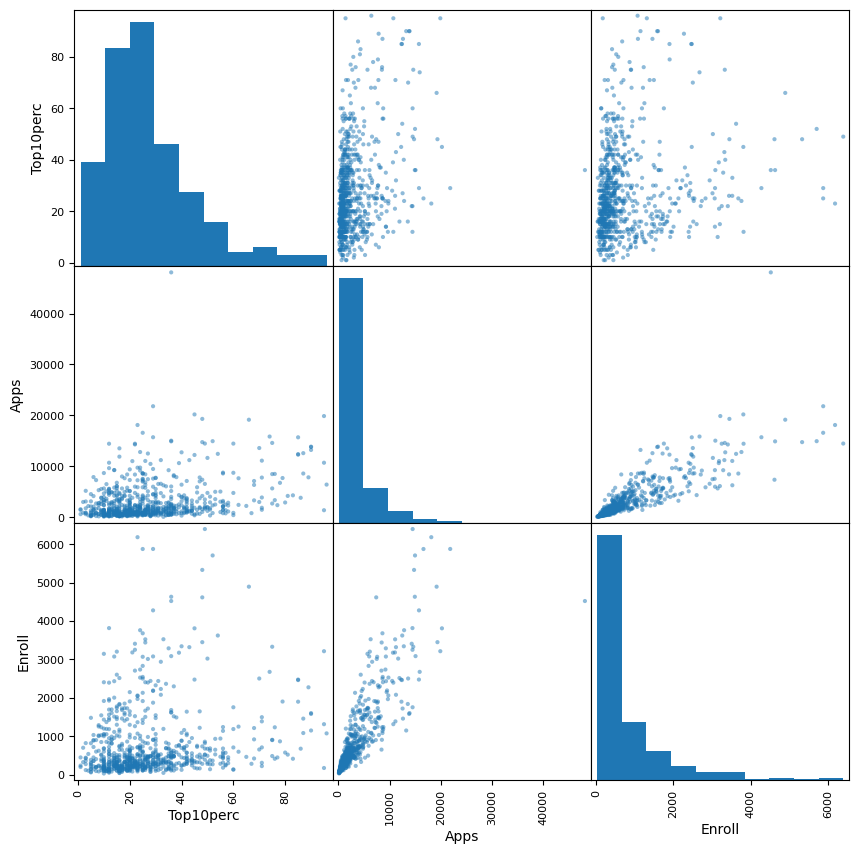

In [12]:
pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']], figsize=(10, 10))

<Axes: title={'center': 'Outstate'}, xlabel='Private'>

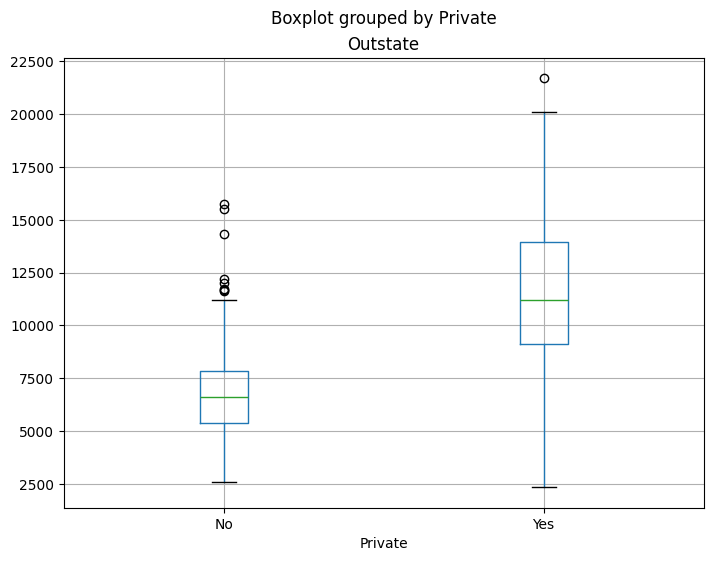

In [15]:
college.boxplot(column='Outstate', by='Private', figsize=(8, 6))

In [19]:
college['Elite'] = pd.cut(college['Top10perc'], bins=[0, 50, 100], labels=['No', 'Yes'])

college['Elite'].value_counts()

Elite
No     699
Yes     78
Name: count, dtype: int64

<Axes: title={'center': 'Outstate'}, xlabel='Elite'>

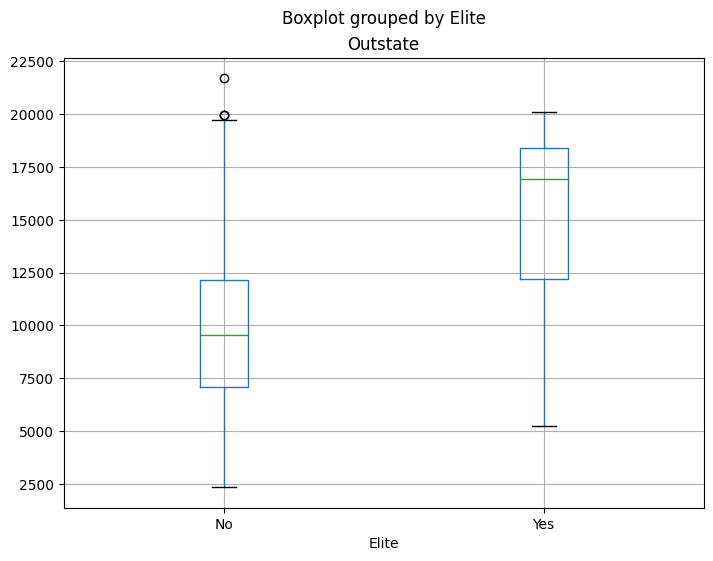

In [20]:
college.boxplot(column='Outstate', by='Elite', figsize=(8, 6))

9.

In [22]:
auto = pd.read_csv('./data/Auto.csv')
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [23]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [24]:
auto.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

In [25]:
auto.describe()

,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [28]:
auto_subset = auto.drop(auto.index[10:86])
print(auto_subset.shape)
auto_subset.describe()


(321, 9)


,mpg,cylinders,displacement,weight,acceleration,year,origin
count,321.000000,321.000000,321.000000,321.000000,321.000000,321.000000,321.000000
mean,24.444860,5.370717,187.174455,2933.183801,15.709034,77.143302,1.598131
std,7.899928,1.653486,99.864568,809.638650,2.706441,3.128202,0.816163
min,11.000000,3.000000,68.000000,1649.000000,8.500000,70.000000,1.000000
25%,18.000000,4.000000,100.000000,2215.000000,14.000000,75.000000,1.000000
50%,23.900000,4.000000,145.000000,2795.000000,15.500000,77.000000,1.000000
75%,30.700000,6.000000,250.000000,3504.000000,17.300000,80.000000,2.000000
max,46.600000,8.000000,455.000000,4997.000000,24.800000,82.000000,3.000000


array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement'>,
        <Axes: xlabel='weight', ylabel='displacement'>,
        <Axes: xlabel='acceleration', ylabel='di

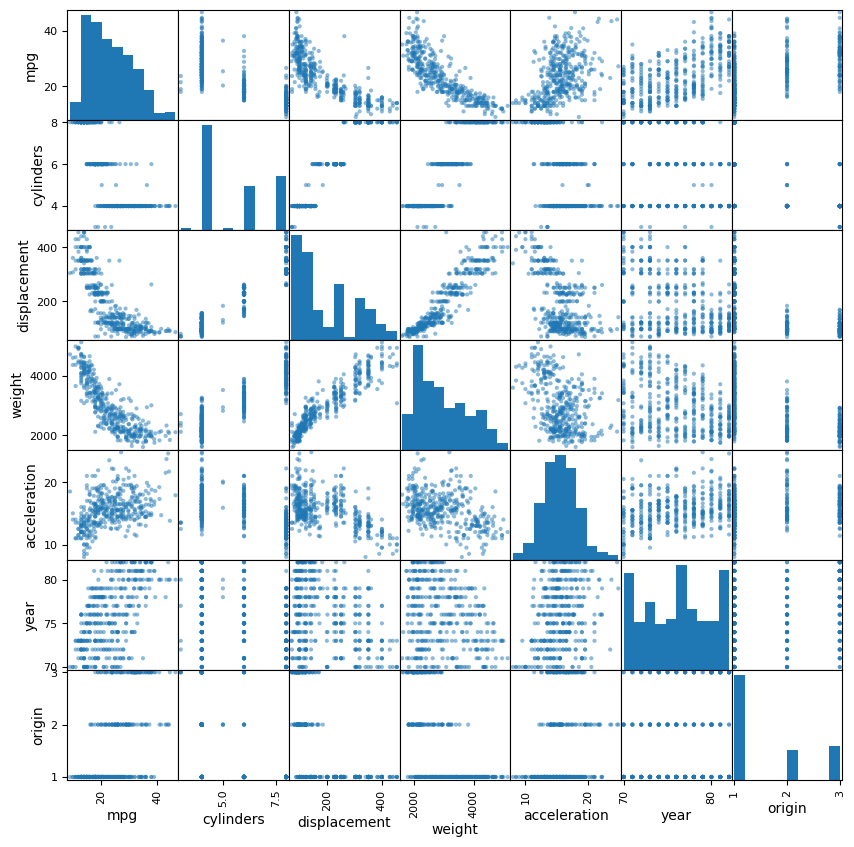

In [29]:
pd.plotting.scatter_matrix(auto, figsize=(10, 10))

10. 

In [30]:
boston = pd.read_csv('./data/Boston.csv')
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [31]:
boston.shape

(506, 14)

In [32]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [33]:
boston.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000
